# Banking transactions churn:

data set:  /kaggle/input/datasets/brindamjune/indian-banking-transactions-2019-to-2024/indian_banking_transactions.csv

In [1]:
library(readxl)
library(tidyverse)
b <- read.csv("/kaggle/input/datasets/brindamjune/indian-banking-transactions-2019-to-2024/indian_banking_transactions.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Statistical summary

In [2]:
summary(b)

 transaction_id     customer_id        transaction_date   transaction_time  
 Length:550000      Length:550000      Length:550000      Length:550000     
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
 account_type       transaction_type   transaction_amount transaction_direction
 Length:550000      Length:550000      Min.   :       2   Length:550000        
 Class :character   Class :character   1st Qu.:     763   Class :character     
 Mode  :character   Mode  :character   Median :    2036   Mode  :character     
                                       Mean   :   29907                        
                                       3rd Qu.:    8557      

Data set consists of 550,000 retail banking transactions spanning from 2019 to 2024. It consists of 20 columns(Attributes).

# Preprocessing:
Checking for missing data

In [3]:
#EDA: Preprocessing and cleaning 
b %>% map(~sum(is.na( . )))

$transaction_id
[1] 0

$customer_id
[1] 0

$transaction_date
[1] 0

$transaction_time
[1] 0

$account_type
[1] 0

$transaction_type
[1] 0

$transaction_amount
[1] 0

$transaction_direction
[1] 0

$account_balance
[1] 0

$merchant_category
[1] 0

$state
[1] 0

$credit_score
[1] 0

$has_loan
[1] 0

$loan_type
[1] 0

$emi_amount
[1] 0

$transaction_status
[1] 0

$channel
[1] 0

$kyc_status
[1] 0

$is_fraud
[1] 0

$transaction_hour
[1] 0

The result shows all Zero, which means there are no Null values in any column.

# Summarizing key metrics:

In [4]:
# Average transaction amount by account type:
b %>%
  group_by(account_type) %>%
  summarise(avg_amount = mean(transaction_amount, na.rm = TRUE))

account_type,avg_amount
<chr>,<dbl>
Current,29884.55
Fixed Deposit,30158.47
NRI,30630.40
Salary,30081.67
Savings,29645.18


In [5]:
# Transaction volume by payment method:
b %>%
  count(transaction_type, sort = TRUE)

transaction_type,n
<chr>,<int>
UPI,153986
IMPS,77038
NEFT,66615
POS,60278
ATM_Withdrawal,55106
Net_Banking,38458
RTGS,32964
Auto_Debit,27418
Cheque,21711


# Correlation analysis:
Analyzing how money moves through the system, Visualizing using Box plot

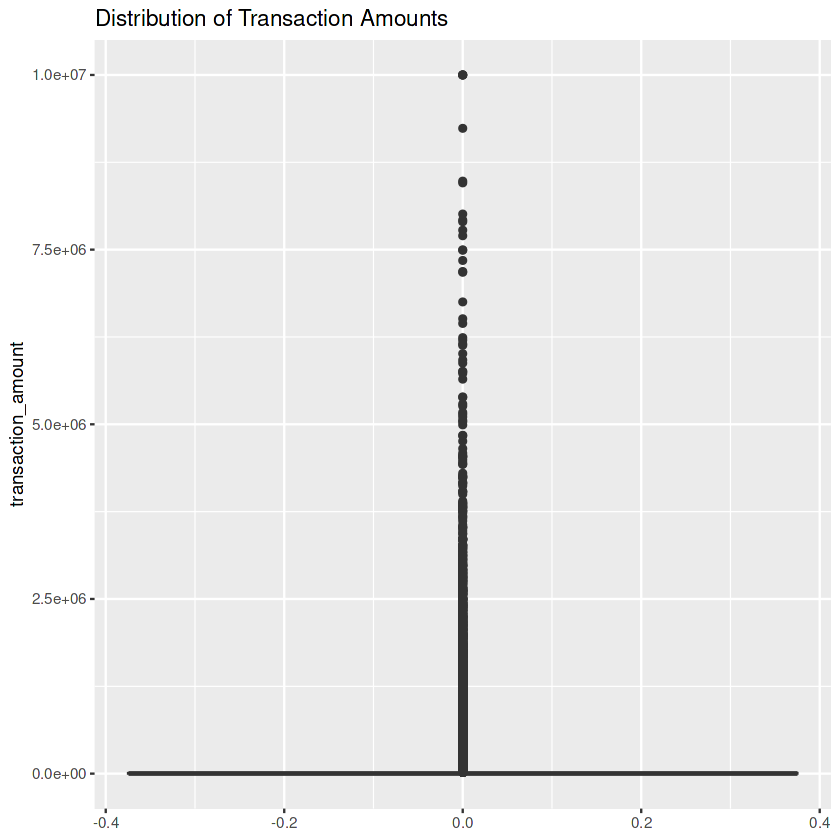

In [6]:
# Transaction amount distribution:
ggplot(b, aes(y = transaction_amount)) + geom_boxplot(fill = "steelblue") + labs(title = "Distribution of Transaction Amounts")



The Box plot shows the spread and helps identify outliers.

In [7]:
# Most Frequent Transaction Types: Count methods like UPI, NEFT, and IMPS.
b %>%
  count(transaction_type) %>%
  mutate(percentage = n / sum(n) * 100) %>%
  arrange(desc(n))

transaction_type,n,percentage
<chr>,<int>,<dbl>
UPI,153986,27.997455
IMPS,77038,14.006909
NEFT,66615,12.111818
POS,60278,10.959636
ATM_Withdrawal,55106,10.019273
Net_Banking,38458,6.992364
RTGS,32964,5.993455
Auto_Debit,27418,4.985091
Cheque,21711,3.947455


In [8]:
#Georaphic Distribution
b %>%
  group_by(state) %>%
  summarise(
    total_volume = n(),
    total_value = sum(transaction_amount)
  ) %>%
  slice_max(total_volume, n = 10) 

# Top 10 states

state,total_volume,total_value
<chr>,<int>,<dbl>
Maharashtra,98911,2980264902
Karnataka,76659,2256631611
Tamil Nadu,71747,2148851576
Delhi,66114,1981774201
Gujarat,54798,1682204920
Telangana,49610,1426830259
West Bengal,43950,1315250791
Rajasthan,38725,1170165310
UP,27414,839996022


In [9]:
# to quantify the baseline fraud rate withing the dataset
b %>%
  count(is_fraud) %>%
  mutate(prop = n / sum(n))

is_fraud,n,prop
<int>,<int>,<dbl>
0,545127,0.99114
1,4873,0.00886


# Fraud Prediction:

In [10]:
#fraud detection:
library(tidymodels)
library(themis) # For handling class imbalance (SMOTE)

# Prepare the data
fraud_df <- b %>%
  mutate(is_fraud = as.factor(ifelse(is_fraud == 1, "fraud", "legit"))) %>%
  select(is_fraud, transaction_amount, transaction_type, 
         channel, credit_score)

# Split into Training (75%) and Testing (25%)
set.seed(123)
data_split <- initial_split(fraud_df, prop = 0.75, strata = is_fraud)
train_data <- training(data_split)
test_data  <- testing(data_split)

fraud_recipe <- recipe(is_fraud ~ ., data = train_data) %>%
  step_dummy(all_nominal_predictors()) %>% # Convert text to numbers
  step_smote(is_fraud) # Balance the classes 

# Define the model
rf_spec <- rand_forest(trees = 500) %>%
  set_engine("ranger") %>%
  set_mode("classification")

# Create a workflow
fraud_workflow <- workflow() %>%
  add_recipe(fraud_recipe) %>%
  add_model(rf_spec)

# Fit the model
fraud_fit <- fit(fraud_workflow, data = train_data)

# Predict on test data
results <- test_data %>%
  select(is_fraud) %>%
  bind_cols(predict(fraud_fit, test_data))

# View Confusion Matrix
conf_mat(results, truth = is_fraud, estimate = .pred_class)

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──



✔ broom        1.0.7     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.2.1
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.1.0
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     



── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages



          Truth
Prediction  fraud  legit
     fraud     53    573
     legit   1157 135717

In [11]:
#Fraud rate: calculation of overall percentage of fraudulent transactions in the dataset
library(dplyr)

fraud_summary <- b %>%
  summarise(
    total_transactions = n(),
    fraud_count = sum(is_fraud == 1),
    non_fraud_count = sum(is_fraud == 0),
    fraud_rate_pct = (fraud_count / total_transactions) * 100
  )

print(fraud_summary)

  total_transactions fraud_count non_fraud_count fraud_rate_pct
1             550000        4873          545127          0.886


Transaction Type: Features like UPI vs. RTGS often have different risk profiles.

Credit Score: Low credit scores combined with high transaction amounts often trigger alerts.

SMOTE: This ensures the model learns the specific patterns of the 0.89% of fraudulent cases rather than ignoring them.

# Classification: 

Customer segmentation using K-means clustering algorithm: 

    Analyzing spending patterns across different demographics and account types.

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3995800)”


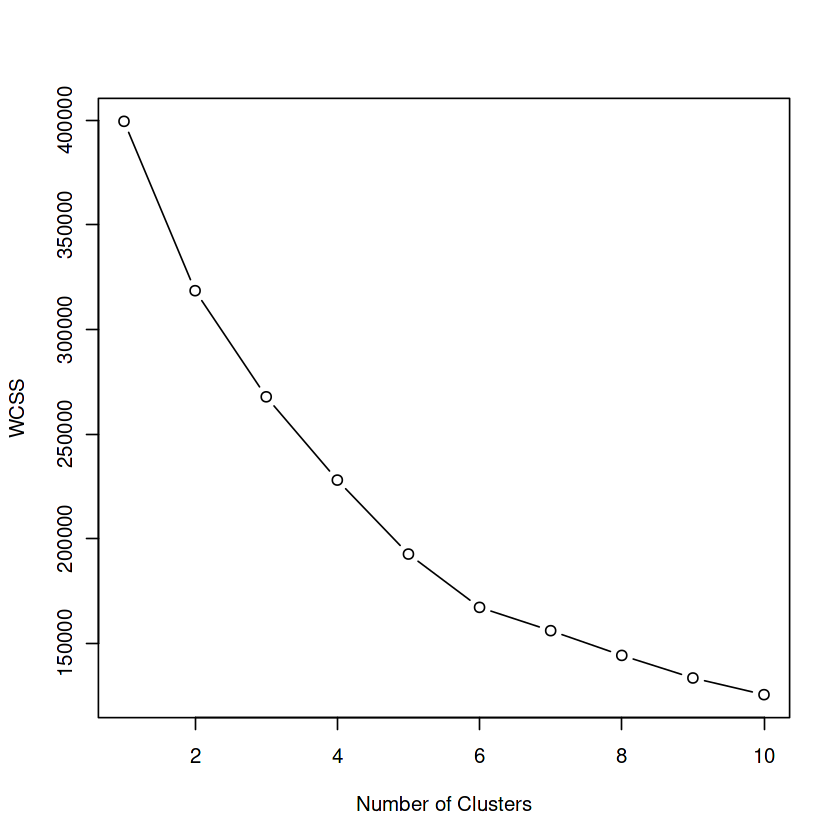

In [12]:
#Customer segmentation: Behavioral segmentation using the K-means clustering algorithm

library(tidyverse)

# Aggregating data by Customer ID to create behavioral features
customer_segments <- b %>%
  group_by(customer_id) %>%
  summarise(
    avg_transaction = mean(transaction_amount),
    total_spend = sum(transaction_amount),
    avg_balance = mean(account_balance),
    transaction_count = n(),
    credit_score = mean(credit_score)
  )

# Removing non-numeric ID for clustering and scaling
segmentation_matrix <- customer_segments %>%
  select(-customer_id) %>%
  scale()

wcss <- map_dbl(1:10, function(k) {
  kmeans(segmentation_matrix, centers = k, nstart = 25)$tot.withinss
})

plot(1:10, wcss, type = "b", xlab = "Number of Clusters", ylab = "WCSS")

set.seed(42)
km_result <- kmeans(segmentation_matrix, centers = 4, nstart = 25)

# Add cluster labels back to original customer data
customer_segments$cluster <- as.factor(km_result$cluster)

We can identify groups of spenders: Frugal (lower transaction amount but high account balances), High-value active users (High transaction frequency and high total spend), and Struggling users (Users with lower balances but frequent digital-UPI transactions)

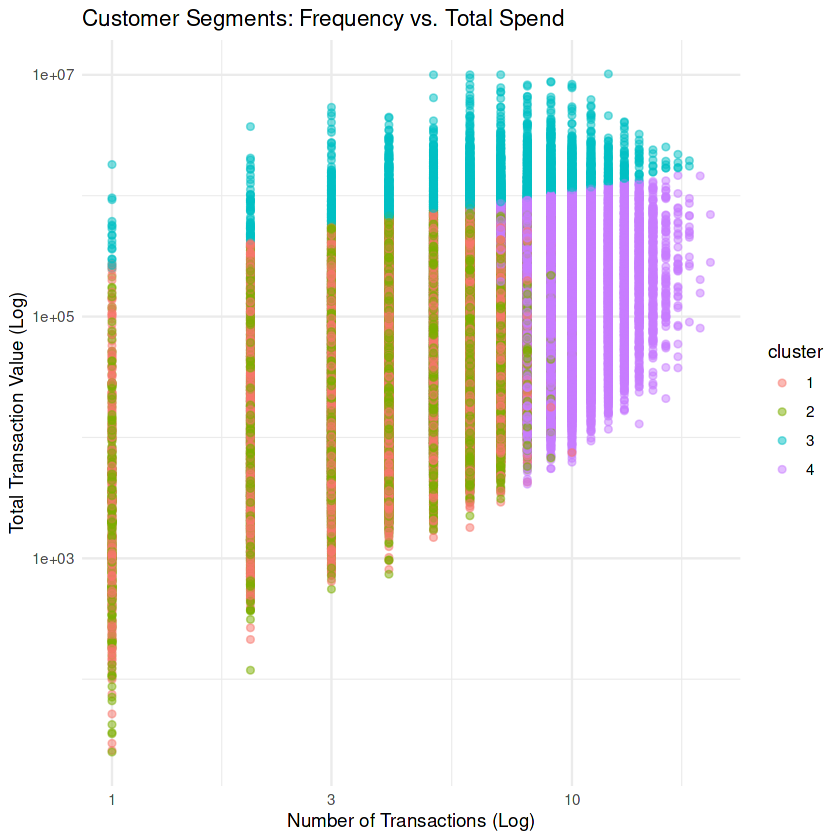

In [13]:
#Visualizing clusters to help identify distinct groups like "High-value frequent user" vs " Low-value occasional users"

library(ggplot2)

# Scatter plot of Total Spend vs Transaction Count colored by Cluster
ggplot(customer_segments, aes(x = transaction_count, y = total_spend, color = cluster)) +
  geom_point(alpha = 0.5) +
  scale_y_log10() + # Use log scale for large financial variations
  scale_x_log10() +
  theme_minimal() +
  labs(title = "Customer Segments: Frequency vs. Total Spend",
       x = "Number of Transactions (Log)", y = "Total Transaction Value (Log)")

# RFM analysis:
RFM is a standard banking technique to determine which customers are the most valuable. 
Recency(R): Days since the last transaction.
Frequency(F): How oftenthey transact
Monetary(M): Total value of their transactions

In [14]:
library(tidyverse)
library(lubridate)

# 1. Convert the date column first
b <- b %>%
  mutate(transaction_date = as.Date(transaction_date)) # Or use ymd(transaction_date)

analysis_date <- as.Date("2024-02-01")

rfm_table <- b %>%
  group_by(customer_id) %>%
  summarise(
    Recency = as.numeric(analysis_date - max(transaction_date, na.rm = TRUE)),
    Frequency = n(),
    Monetary = sum(transaction_amount, na.rm = TRUE)
  ) %>%
  mutate(
    R_Score = ntile(desc(Recency), 5), 
    F_Score = ntile(Frequency, 5),      
    M_Score = ntile(Monetary, 5),       
    Total_RFM = R_Score + F_Score + M_Score
  )

rfm_table

customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_RFM
<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>
CUST000001,47,5,3276.58,5,1,1,7
CUST000002,788,7,152940.68,1,3,4,8
CUST000003,195,8,119842.16,3,4,3,10
CUST000004,365,8,123820.11,2,4,4,10
CUST000005,145,5,66083.27,4,1,3,8
CUST000006,346,12,203916.60,2,5,4,11
CUST000007,907,4,33662.12,1,1,2,4
CUST000008,840,3,20088.52,1,1,2,4
CUST000009,217,8,612906.06,3,4,5,12


Now using this we can categorize customers based on their 
total_RFM score:
Champions (score of 14-15) - bought recently, buy often and spend most.
AtRisk (score below 6) - haven't done any transaction in a long time and were low-value

The heat map can visualize this.

`summarise()` has grouped output by 'R_Score'. You can override using the
`.groups` argument.


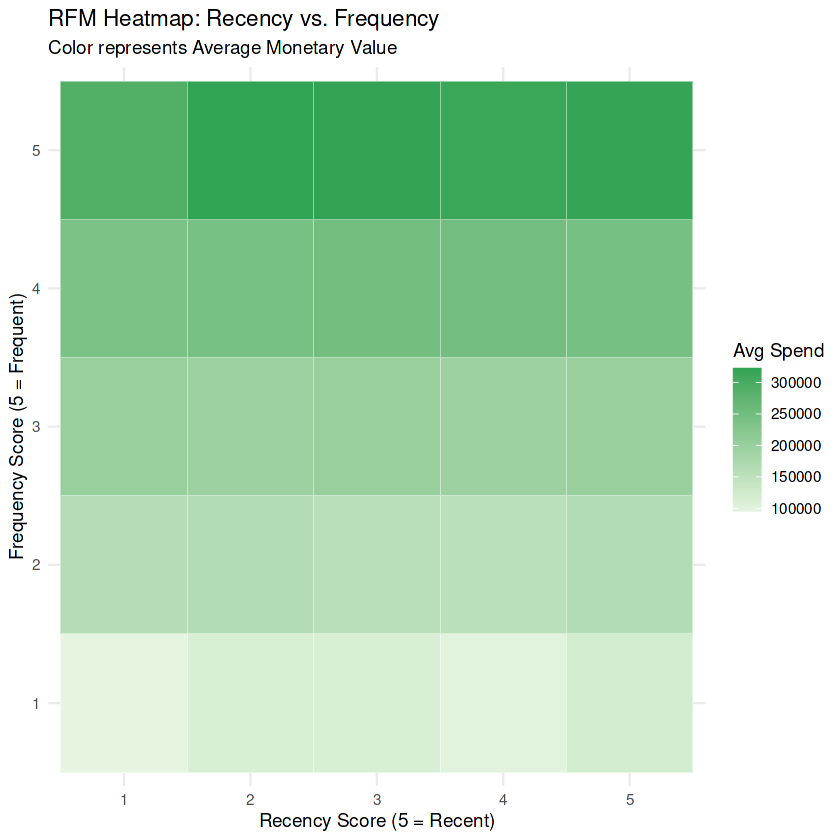

In [15]:
library(ggplot2)

# Summarize data for the heatmap
rfm_heatmap_data <- rfm_table %>%
  group_by(R_Score, F_Score) %>%
  summarise(Avg_Monetary = mean(Monetary, na.rm = TRUE))


# Generate the Heatmap
ggplot(rfm_heatmap_data, aes(x = factor(R_Score), y = factor(F_Score), fill = Avg_Monetary)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "#e5f5e0", high = "#31a354") + # Green gradient for value
  labs(
    title = "RFM Heatmap: Recency vs. Frequency",
    subtitle = "Color represents Average Monetary Value",
    x = "Recency Score (5 = Recent)",
    y = "Frequency Score (5 = Frequent)",
    fill = "Avg Spend"
  ) +
  theme_minimal()

According to heat map:
Top-right corner (5,5) - New customers
Top-left corner (5,1) - At Risk / Loyal but dormant user
Bottom-left corner (1,1) - Lost customer with low frequency and long absence

In [16]:
#RFM summary
rfm_summary <- rfm_table %>%
  group_by(Total_RFM) %>%
  summarise(
    Avg_Recency = mean(Recency),
    Avg_Frequency = mean(Frequency),
    Avg_Monetary = mean(Monetary),
    Customer_Count = n()
  ) %>%
  arrange(desc(Total_RFM))

print(rfm_summary)

# A tibble: 13 × 5
   Total_RFM Avg_Recency Avg_Frequency Avg_Monetary Customer_Count
       <int>       <dbl>         <dbl>        <dbl>          <int>
 1        15        58.8         11.0       732514.           1572
 2        14        84.4         10.3       522351.           3610
 3        13       114.           9.61      420502.           5779
 4        12       149.           8.93      340130.           7637
 5        11       185.           8.14      271125.           8641
 6        10       224.           7.46      209341.           9317
 7         9       263.           6.76      174372.           9069
 8         8       311.           6.14      137731.           8526
 9         7       355.           5.39      100466.           7821
10         6       416.           4.95       52193.           6144
11         5       490.           4.50       29675.           4808
12         4       584.           3.91       16651.           3670
13         3       854.           2.93     

# At risk segmentation:
#To compare the "At Risk" customers with "Champions" to reveal if certain types or lower credit scores are associated with customers who stop using their account

Segment,Avg_Credit_Score,Median_Credit_Score,Avg_Balance
<chr>,<dbl>,<dbl>,<dbl>
At Risk,599.5953,600,83207.78
Champion,600.1623,600,85575.28


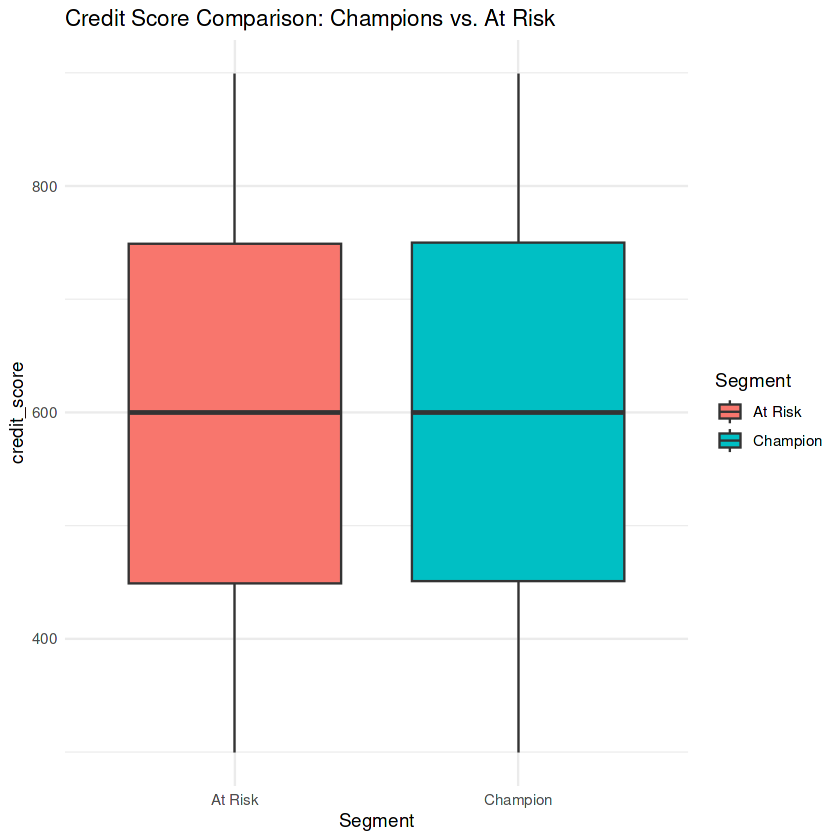

In [17]:

# Define segments
rfm_segmented <- rfm_table %>%
  mutate(Segment = case_when(
    Total_RFM >= 14 ~ "Champion",
    Total_RFM <= 6  ~ "At Risk",
    TRUE            ~ "Other"
  ))

# Join with original data to get Credit Score and Account Type
comparison_data <- b %>%
  inner_join(rfm_segmented %>% select(customer_id, Segment), by = "customer_id") %>%
  filter(Segment %in% c("Champion", "At Risk"))

# Summary of Credit Scores by Segment
comparison_data %>%
  group_by(Segment) %>%
  summarise(
    Avg_Credit_Score = mean(credit_score, na.rm = TRUE),
    Median_Credit_Score = median(credit_score, na.rm = TRUE),
    Avg_Balance = mean(account_balance, na.rm = TRUE)
  )

# Visualization
ggplot(comparison_data, aes(x = Segment, y = credit_score, fill = Segment)) +
  geom_boxplot() +
  labs(title = "Credit Score Comparison: Champions vs. At Risk") +
  theme_minimal()

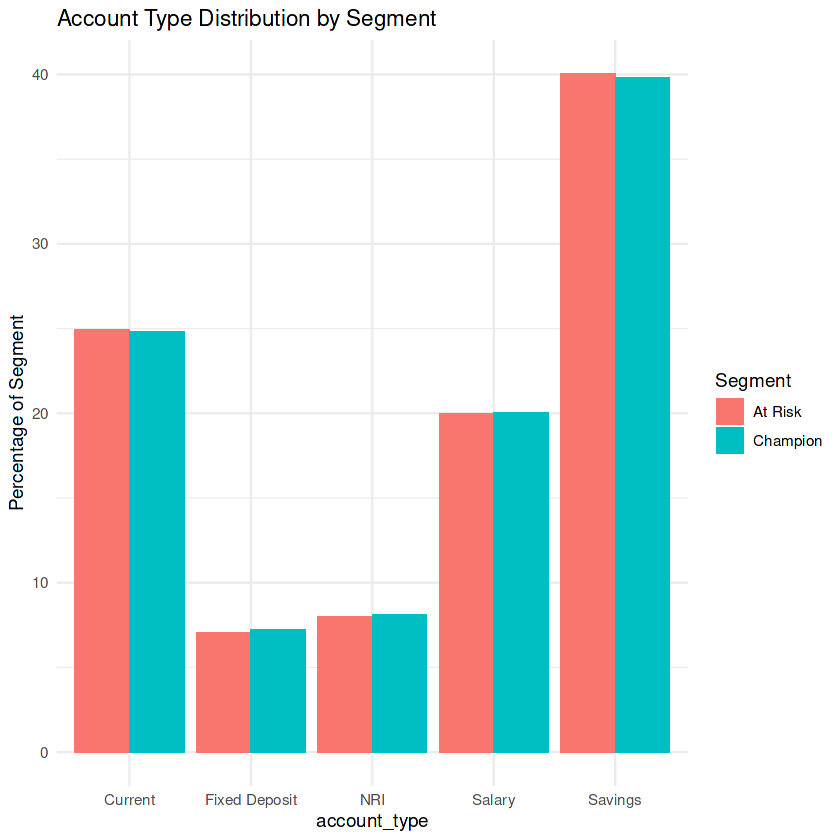

In [18]:
# Account Type Distribution
comparison_data %>%
  count(Segment, account_type) %>%
  group_by(Segment) %>%
  mutate(Percentage = n / sum(n) * 100) %>%
  ggplot(aes(x = account_type, y = Percentage, fill = Segment)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Account Type Distribution by Segment", y = "Percentage of Segment") +
  theme_minimal()

# Logistic Regression model:
To predict the probability of a customer becoming "At Risk", we use logistic regression model. It helps provide clear "odds ratio"- to show how much 10-point drop in credit score or a specific account type increases the risk of customer churning.

In [19]:
#logistic regression model to predict the probability of a customer becoming "At Risk"

# Prepare data for modeling
model_data <- rfm_segmented %>%
  filter(Segment %in% c("Champion", "At Risk")) %>%
  mutate(is_at_risk = ifelse(Segment == "At Risk", 1, 0)) %>%
  # Join with demographic features from original data
  left_join(b %>% 
              distinct(customer_id, .keep_all = TRUE) %>% 
              select(customer_id, credit_score, account_type), 
            by = "customer_id")

# Set factors
model_data$account_type <- as.factor(model_data$account_type)

In [20]:
# Fit the model
risk_model <- glm(is_at_risk ~ credit_score + account_type, 
                  data = model_data, 
                  family = "binomial")

# View the results
summary(risk_model)


Call:
glm(formula = is_at_risk ~ credit_score + account_type, family = "binomial", 
    data = model_data)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                1.194e+00  6.281e-02  19.010   <2e-16 ***
credit_score               6.662e-05  9.051e-05   0.736    0.462    
account_typeFixed Deposit -9.328e-02  6.625e-02  -1.408    0.159    
account_typeNRI           -4.572e-02  6.293e-02  -0.727    0.467    
account_typeSalary         5.968e-02  4.760e-02   1.254    0.210    
account_typeSavings        1.693e-02  4.019e-02   0.421    0.674    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 24607  on 23125  degrees of freedom
Residual deviance: 24600  on 23120  degrees of freedom
AIC: 24612

Number of Fisher Scoring iterations: 4


The variable has ***, so it is strong predictor of churn.
a negative estimate for credit_score means that as the score goes up, the probability of being at risk goes down.
Also, some specific accounts (Savings) have a higher estimate, meaning they are more likely to become inactive compared to the baseline.

# Predict and evaluate logistic regression model

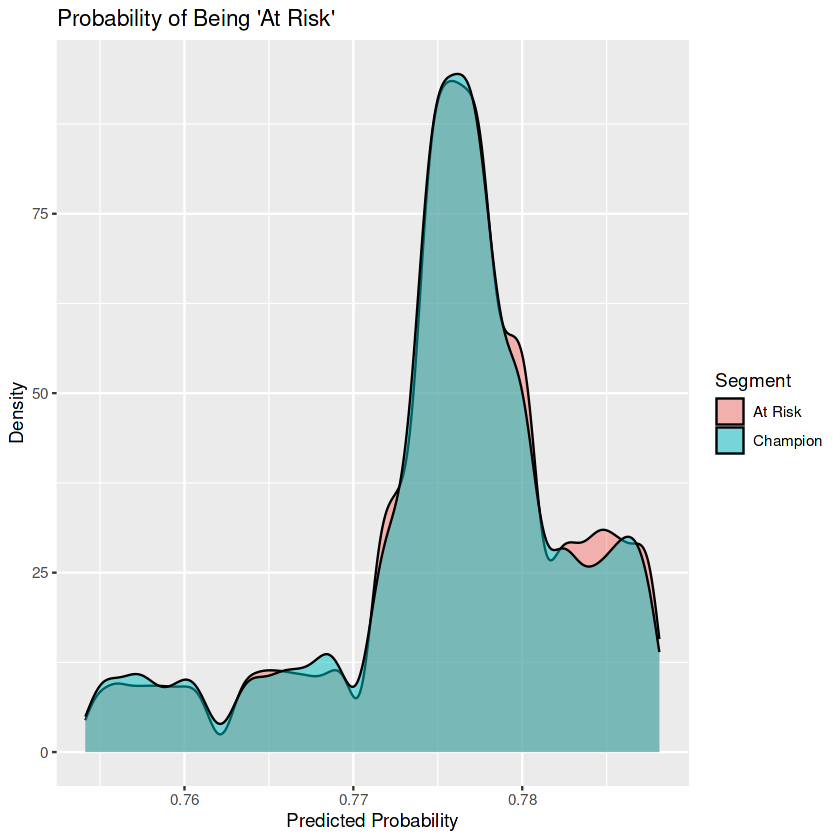

In [21]:
# Predict probabilities
model_data$risk_prob <- predict(risk_model, type = "response")

# Visualizing the distribution of risk
ggplot(model_data, aes(x = risk_prob, fill = Segment)) +
  geom_density(alpha = 0.5) +
  labs(title = "Probability of Being 'At Risk'",
       x = "Predicted Probability", y = "Density")


Banks can use this model on active customers. 
If an active customer's risk probability crosses a threshold ( say 0.70), the bank can trigger an automated loyalty offer or a simple phone call before they actually stop transacting.

# Odds ratios to determine the strongest driver of customer risk:

In [22]:

# Extract coefficients and exponentiate them
odds_ratios <- exp(coef(risk_model))

# Calculate Confidence Intervals for reliability
conf_intervals <- exp(confint(risk_model))

# Combine into a clean table
risk_drivers <- data.frame(
  Feature = names(odds_ratios),
  Odds_Ratio = odds_ratios,
  Lower_CI = conf_intervals[,1],
  Upper_CI = conf_intervals[,2]
) %>%
  arrange(desc(Odds_Ratio))

print(risk_drivers)

Waiting for profiling to be done...



                                            Feature Odds_Ratio  Lower_CI
(Intercept)                             (Intercept)  3.3004395 2.9189261
account_typeSalary               account_typeSalary  1.0614992 0.9670405
account_typeSavings             account_typeSavings  1.0170725 0.9399085
credit_score                           credit_score  1.0000666 0.9998892
account_typeNRI                     account_typeNRI  0.9553048 0.8450082
account_typeFixed Deposit account_typeFixed Deposit  0.9109349 0.8006216
                          Upper_CI
(Intercept)               3.733876
account_typeSalary        1.165445
account_typeSavings       1.100294
credit_score              1.000244
account_typeNRI           1.081459
account_typeFixed Deposit 1.038094


When odds ratio 
OR > 1 : feature increases the risk 
e.g., if account_typeSavings has an OR of 1.5, savings holders are 50% more likely to be "At Risk" than the baseline account type).

OR < 1 : feature decrease the risk
e.g., if credit_score has an OR of 0.95, then for every 1-point increase in credit score, the odds of churn drop by 5%.

OR = 1 : feature has no significant impact on risk.

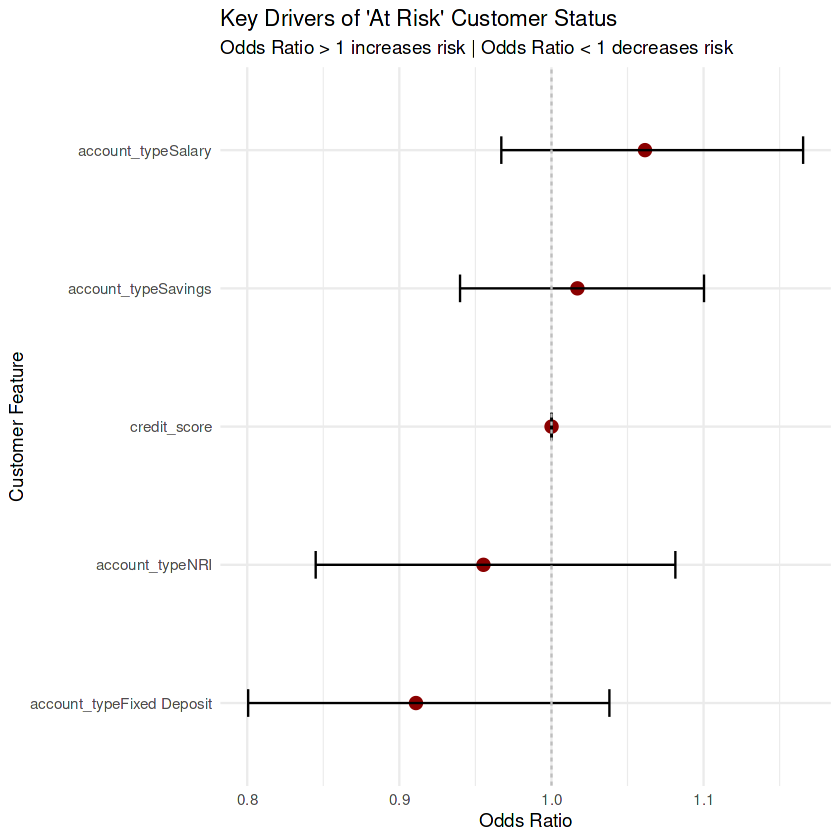

In [23]:
#Visualizing risk drivers:
ggplot(risk_drivers[-1, ], aes(x = reorder(Feature, Odds_Ratio), y = Odds_Ratio)) +
  geom_point(size = 3, color = "darkred") +
  geom_errorbar(aes(ymin = Lower_CI, ymax = Upper_CI), width = 0.2) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray") +
  coord_flip() +
  labs(
    title = "Key Drivers of 'At Risk' Customer Status",
    subtitle = "Odds Ratio > 1 increases risk | Odds Ratio < 1 decreases risk",
    x = "Customer Feature",
    y = "Odds Ratio"
  ) +
  theme_minimal()

# Strategic insight

The highest odds ratio, shows banks exactly where to focus. 
For instance, if younger age or UPI transactions show high risk, the bank might need to improve the mobile app experience or digital rewards.